In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
# plot settings
mpl.rcParams['font.family'] = 'Liberation Serif'
mpl.rcParams['font.size'] = 15
mpl.rcParams['font.weight'] = 'bold'
mpl.rcParams['axes.labelweight'] = 'bold'
mpl.rcParams['axes.titleweight'] = 'bold'
mpl.rcParams['axes.titlesize'] = 15
mpl.rcParams['axes.labelsize'] = 15
mpl.rcParams['xtick.labelsize'] = 15
mpl.rcParams['ytick.labelsize'] = 15
mpl.rcParams['legend.fontsize'] = 15
mpl.rcParams['savefig.dpi'] = 600

In [2]:
X = np.array([
    [0,0],
    [0,1],
    [1,0],
    [1,1]
])

y = np.array([[0],
              [1],
              [1],
              [0]])

In [3]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))


def sigmoid_derivative(x):
    return x * (1 - x)

In [13]:
def initialize_network():
    # Xavier initialization: scale weights by sqrt(2 / fan_in + fan_out)
    # This prevents vanishing/exploding gradients and breaks symmetry reliably.

    W1 = np.random.randn(2, 4) * np.sqrt(2.0 / (2 + 4))  # 2 inputs → 4 hidden
    b1 = np.zeros((1, 4))

    W2 = np.random.randn(4, 1) * np.sqrt(2.0 / (4 + 1))  # 4 hidden → 1 output
    b2 = np.zeros((1, 1))

    return W1, b1, W2, b2


In [14]:
def forward(X, W1, b1, W2, b2):

    hidden_input = np.dot(X, W1) + b1
    hidden_output = sigmoid(hidden_input)

    output_input = np.dot(hidden_output, W2) + b2
    predicted = sigmoid(output_input)

    return hidden_output, predicted

In [15]:
def backward(X, y,
             hidden_output,
             predicted,
             W2,
             learning_rate):

    output_error = y - predicted
    output_delta = output_error * sigmoid_derivative(predicted)

    hidden_error = output_delta.dot(W2.T)
    hidden_delta = hidden_error * sigmoid_derivative(hidden_output)

    dW2 = hidden_output.T.dot(output_delta)
    db2 = np.sum(output_delta, axis=0, keepdims=True)

    dW1 = X.T.dot(hidden_delta)
    db1 = np.sum(hidden_delta, axis=0, keepdims=True)

    return dW1, db1, dW2, db2

In [34]:
def train_mlp(X, y,
              learning_rate=0.5,
              epochs=1000,
              tolerance=1e-3):

    W1, b1, W2, b2 = initialize_network()

    losses = []
    snapshots = {}

    for epoch in range(epochs + 1):

        # ---------- Forward ----------
        hidden_output, predicted = forward(X, W1, b1, W2, b2)

        loss = np.mean((y - predicted) ** 2)
        losses.append(loss)

        # Save and print every 200 epochs
        if epoch % 500 == 0:

            snapshots[epoch] = (
                W1.copy(),
                b1.copy(),
                W2.copy(),
                b2.copy(),
                epoch

            )

            print("=" * 80)
            print(f"Epoch : {epoch}")
            print(f"Loss  : {loss:.6f}\n")

            print("{:<10}{:<10}{:<10}".format("Input", "Target", "Prediction"))
            for i in range(len(X)):
                print(f"{str(X[i]):<10}{y[i][0]:<10}{predicted[i][0]:.4f}")

            print("\nW1:")
            print(np.round(W1, 4))

            print("\nb1:")
            print(np.round(b1, 4))

            print("\nW2:")
            print(np.round(W2, 4))

            print("\nb2:")
            print(np.round(b2, 4))
            print()

        # Early stopping
        if loss < tolerance:
            print(f"\nConverged at epoch {epoch}")
            break

        # ---------- Backward ----------
        dW1, db1, dW2, db2 = backward(
            X,
            y,
            hidden_output,
            predicted,
            W2,
            learning_rate
        )

        # ---------- Update ----------
        W1 += learning_rate * dW1
        b1 += learning_rate * db1

        W2 += learning_rate * dW2
        b2 += learning_rate * db2

    snapshots["final"] = (
        W1.copy(),
        b1.copy(),
        W2.copy(),
        b2.copy(),
        epoch
    )

    return W1, b1, W2, b2, losses, snapshots

In [35]:
W1, b1, W2, b2, losses, snapshots = train_mlp(
    X,
    y,
    learning_rate=0.5,
    epochs=10000,
    tolerance=1e-3
)

Epoch : 0
Loss  : 0.268531

Input     Target    Prediction
[0 0]     0         0.3711
[0 1]     1         0.3649
[1 0]     1         0.3659
[1 1]     0         0.3619

W1:
[[-0.5242 -0.8154  0.8462 -0.1304]
 [ 0.039  -0.8226 -0.3143  0.064 ]]

b1:
[[0. 0. 0. 0.]]

W2:
[[-0.728 ]
 [ 0.2376]
 [-0.3799]
 [-0.1845]]

b2:
[[0.]]

Epoch : 500
Loss  : 0.240536

Input     Target    Prediction
[0 0]     0         0.4329
[0 1]     1         0.5331
[1 0]     1         0.4886
[1 1]     0         0.5432

W1:
[[-1.0036 -1.2802  1.2506 -0.1455]
 [-0.756  -1.2263 -0.5047  0.0319]]

b1:
[[-0.3681 -0.2051  0.3319 -0.0052]]

W2:
[[-0.7358]
 [-0.8201]
 [-0.5642]
 [ 0.1414]]

b2:
[[0.6572]]

Epoch : 1000
Loss  : 0.069474

Input     Target    Prediction
[0 0]     0         0.1683
[0 1]     1         0.7667
[1 0]     1         0.7093
[1 1]     0         0.3326

W1:
[[-2.6601 -4.3232  3.8705 -0.0099]
 [-2.1882 -3.8147 -1.9831 -2.6504]]

b1:
[[-0.5911  0.8131  0.8695  1.1119]]

W2:
[[-1.765 ]
 [-4.2678]
 [-3.1

In [36]:
from matplotlib.lines import Line2D

def plot_decision_boundary(ax, X, y, W1, b1, W2, b2, title):

    x_min, x_max = -0.5, 1.5
    y_min, y_max = -0.5, 1.5

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]

    _, output = forward(grid, W1, b1, W2, b2)

    Z = (output >= 0.5).astype(int)
    Z = Z.reshape(xx.shape)

    # Decision regions
    ax.contourf(
        xx,
        yy,
        Z,
        levels=[-0.5, 0.5, 1.5],
        cmap="coolwarm",
        alpha=0.35
    )

    # Training samples
    ax.scatter(
        X[:, 0],
        X[:, 1],
        c=y.ravel(),
        cmap="coolwarm",
        edgecolors="black",
        s=120
    )

    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)

    ax.set_xlabel("Input X1")
    ax.set_ylabel("Input X2")
    ax.set_title(title)
    ax.grid(True)

    # Legend
    cmap = plt.cm.coolwarm
    norm = plt.Normalize(vmin=0, vmax=1)

    legend_elements = [
        Line2D([0], [0],
            marker='o',
            color='w',
            label='Target = 0',
            markerfacecolor=cmap(norm(0)),
            markeredgecolor='black',
            markersize=10),

        Line2D([0], [0],
            marker='o',
            color='w',
            label='Target = 1',
            markerfacecolor=cmap(norm(1)),
            markeredgecolor='black',
            markersize=10)
    ]

    ax.legend(handles=legend_elements,
              loc='upper right',
              fontsize=11,frameon=True)

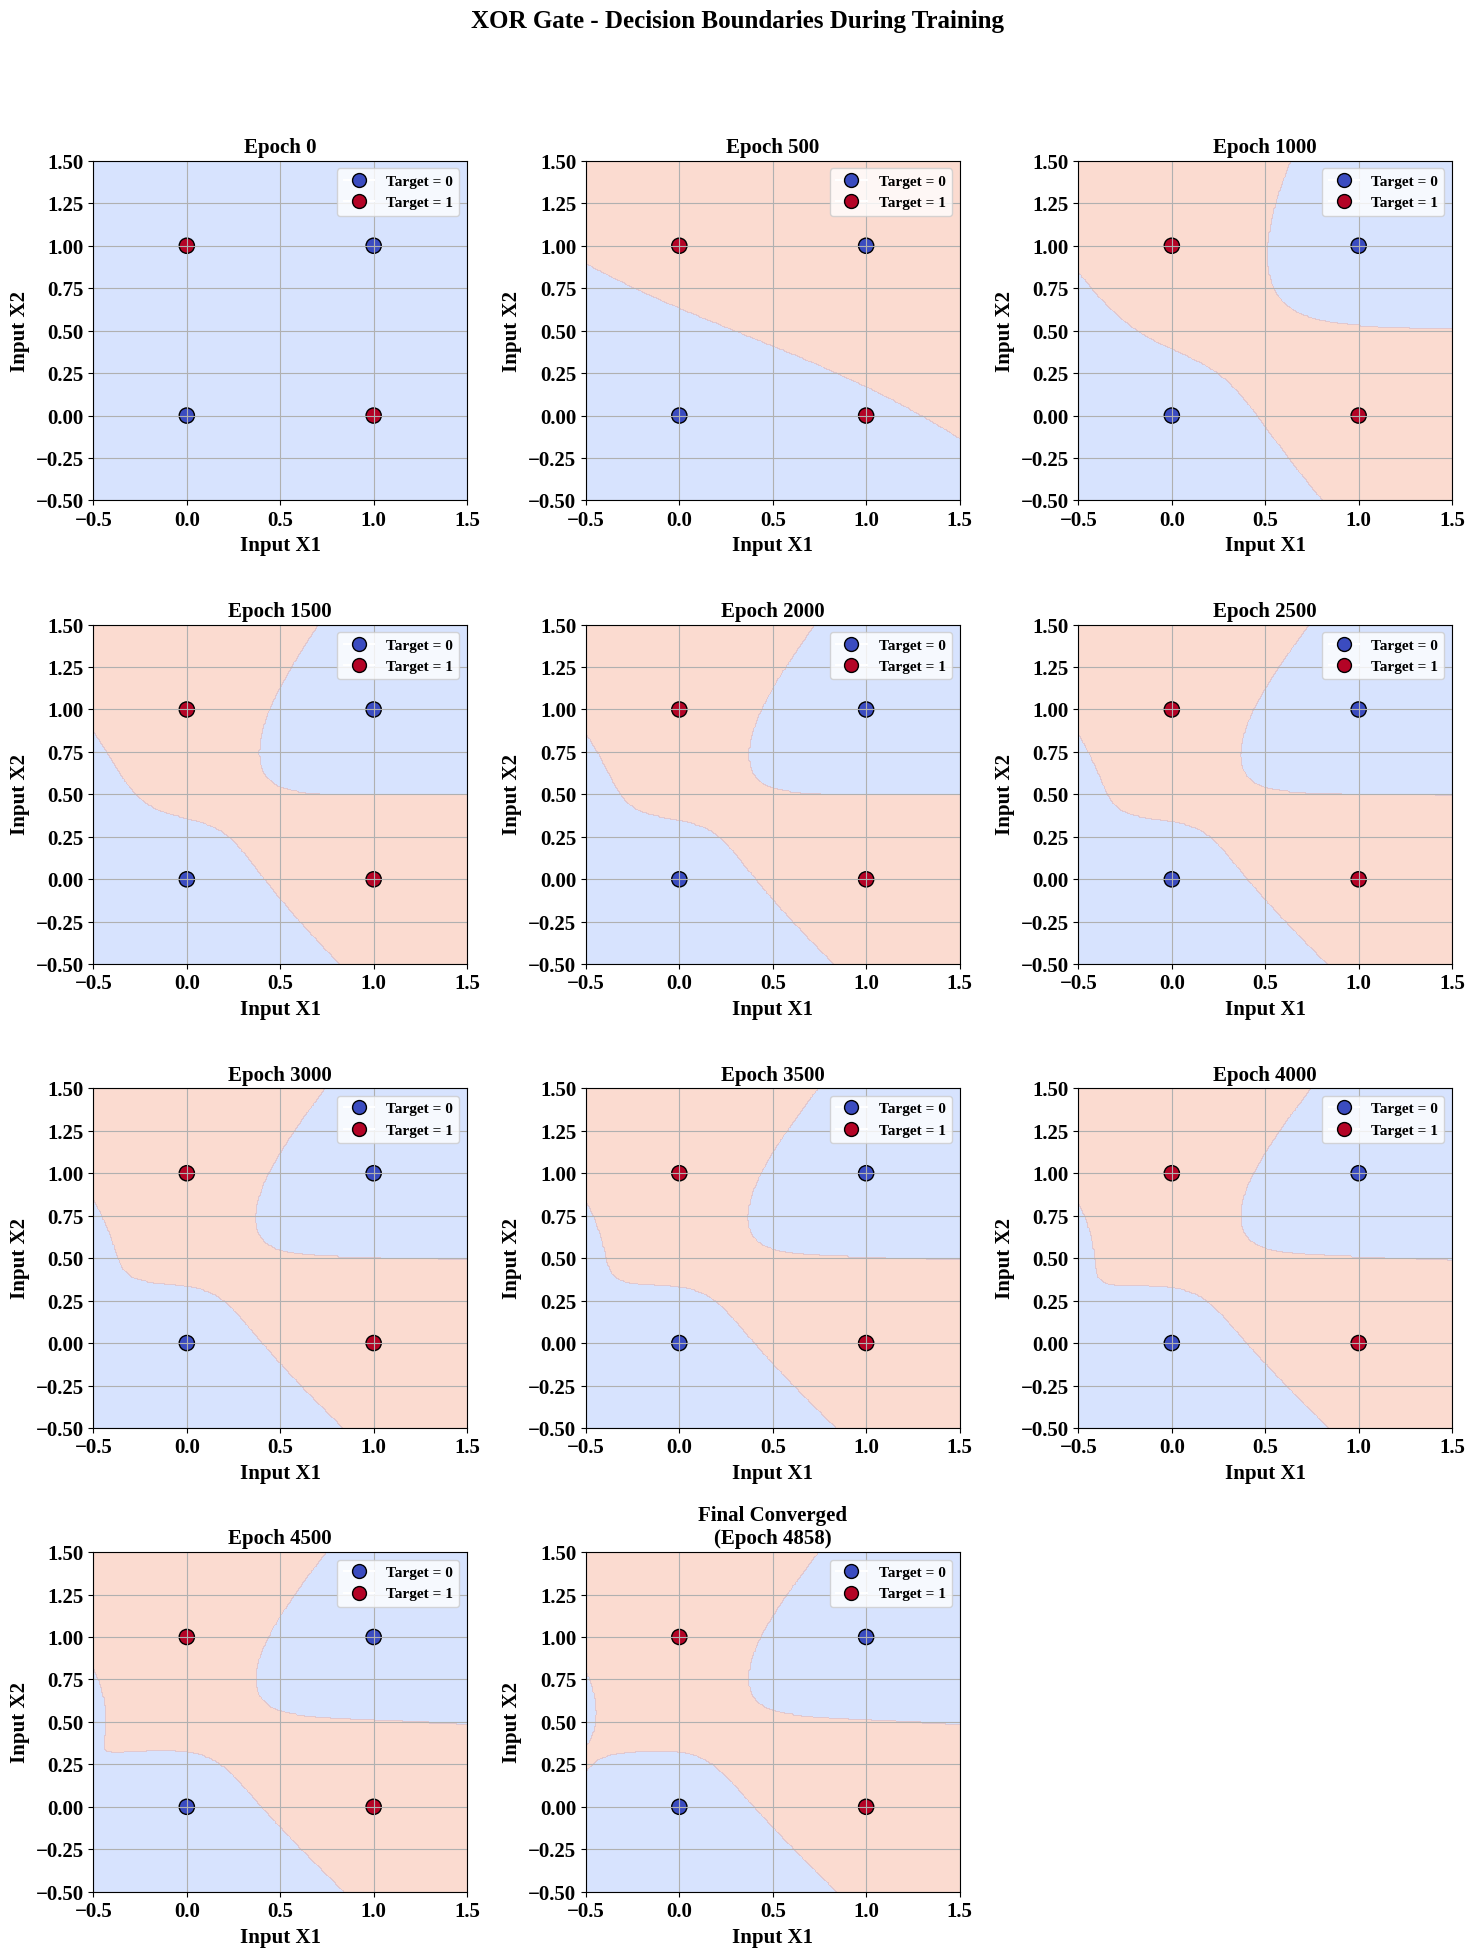

In [38]:
epochs_to_plot = sorted(
    [k for k in snapshots.keys() if isinstance(k, int)]
)

if "final" in snapshots:
    epochs_to_plot.append("final")


cols = 3
rows = (len(epochs_to_plot) + cols - 1) // cols

fig, axes = plt.subplots(
    rows,
    cols,
    figsize=(5*cols, 5*rows)
)

axes = np.array(axes).reshape(-1)

fig.suptitle(
    "XOR Gate - Decision Boundaries During Training",
    fontsize=18,
    fontweight="bold"
)


for ax, ep in zip(axes, epochs_to_plot):

    W1, b1, W2, b2, epoch = snapshots[ep]

    if ep == "final":
        title = f"Final Converged\n(Epoch {epoch})"
    else:
        title = f"Epoch {epoch}"

    plot_decision_boundary(
        ax,
        X,
        y,
        W1,
        b1,
        W2,
        b2,
        title
    )


# Hide unused subplots
for ax in axes[len(epochs_to_plot):]:
    ax.axis("off")


plt.tight_layout(rect=[0, 0, 1, 0.95])

plt.savefig(
    "MLP_XOR.eps",
    format="eps",
    bbox_inches="tight"
)

plt.show()

In [39]:
def predict(X, W1, b1, W2, b2):

    _, output = forward(
        X,
        W1,
        b1,
        W2,
        b2
    )

    return (output >= 0.5).astype(int)

In [40]:
predictions = predict(
    X,
    W1,
    b1,
    W2,
    b2
)

print("Actual Output")
print(y)

print("\nPredicted Output")
print(predictions)

Actual Output
[[0]
 [1]
 [1]
 [0]]

Predicted Output
[[0]
 [1]
 [1]
 [0]]
